                            24AI007->Aditya Kumar->Assignment 2
                   

Part 1: Tabular Data Processing

In [43]:
import pandas as pd
from scipy.io import arff,savemat
import numpy as np
import pickle
import h5py
import sqlite3
import os
import matplotlib.pyplot as plt

In [44]:
def load_all_tabular():
    files = {
        'CSV': 'diabetes.csv',
        'TSV': 'demo_mlexpec.tsv',
        'ARFF': 'dataset_191_wine.arff',
        'XLS': 'datafile.xls',
        'ODS': 'datafile.ods',
        'SXC': 'datafile.sxc',
        'DIF': 'PRML.dif'
    }
    dataframes = {}
    for fmt, path in files.items():
        try:
            if fmt == 'ARFF':
                data, _ = arff.loadarff(path)
                dataframes[fmt] = pd.DataFrame(data)
            elif fmt == 'ODS':
                dataframes[fmt] = pd.read_excel(path, engine='odf')
            elif fmt == 'TSV':
                dataframes[fmt] = pd.read_csv(path, sep='\t')
            elif fmt == 'DIF':
                 dataframes[fmt] = pd.read_csv(path, sep='\t') # DIF is often tab-like
            elif fmt == 'SXC':
                 import pyexcel as p
                 sxc_data = p.get_array(file_name=path)
                 dataframes[fmt] = pd.DataFrame(sxc_data[1:], columns=sxc_data[0])
            else:
                dataframes[fmt] = pd.read_csv(path) if fmt == 'CSV' else pd.read_excel(path)
            
            df = dataframes[fmt]
            # Step 3: Print properties
            print(f"[{fmt}] Size: {df.size} | Shape: {df.shape} | Dims: {df.ndim}")
        except Exception as e:
            print(f"Error loading {fmt}: {e}")
    return dataframes

In [45]:
def perform_matrix_ops(df):

    A = df.select_dtypes(include=[np.number]).iloc[:5, :5].to_numpy()
    print("\n--- Matrix Operations (Step 4) ---")
    print(f"Transpose:\n{A.T}")
    print(f"Dot Product (A.A_T):\n{np.dot(A, A.T)}")
    try:
        print(f"Inverse:\n{np.linalg.inv(A)}")
    except np.linalg.LinAlgError:
        print("Matrix singular; inverse impossible.")
    return A

In [46]:
def viz_and_save(df, matrix_a):
    os.makedirs('processed_output', exist_ok=True)
    
    plt.figure()
    df.iloc[:, 0].plot(kind='line')
    plt.savefig('processed_output/line_graph.png')
    
    plt.figure()
    df.iloc[:, :2].plot(kind='scatter', x=df.columns[0], y=df.columns[1])
    plt.savefig('processed_output/scatter.png')
    plt.close('all') # Free memory
    
    
    df.to_pickle('processed_output/data.pkl')
    np.save('processed_output/matrix.npy', matrix_a)
    np.savez('processed_output/matrix.npz', m=matrix_a)
    
    # Save as MAT (Matlab)
    savemat('processed_output/data.mat', {'vect': matrix_a})
    
    # Save as SQL
    conn = sqlite3.connect('processed_output/data.db')
    df.to_sql('lab_table', conn, if_exists='replace')
    conn.close()
    
    print("\n--- Step 6: All files saved in 'processed_output' folder ---")

In [47]:
if __name__ == "__main__":
    # 1. Load all files
    all_dfs = load_all_tabular()
    
    # 2. Use the CSV dataframe for matrix and viz tasks
    if 'CSV' in all_dfs:
        main_df = all_dfs['CSV']
        
        # 3. Perform Matrix Ops
        mat_a = perform_matrix_ops(main_df)
        
        # 4. Viz and Export
        viz_and_save(main_df, mat_a)
    else:
        print("Failure: diabetes.csv not loaded.")

[CSV] Size: 6912 | Shape: (768, 9) | Dims: 2
[TSV] Size: 910224 | Shape: (14448, 63) | Dims: 2
[ARFF] Size: 2492 | Shape: (178, 14) | Dims: 2
Error loading XLS: Missing optional dependency 'xlrd'. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install xlrd.
Error loading ODS: Missing optional dependency 'odfpy'.  Use pip or conda to install odfpy.
Error loading SXC: No module named 'pyexcel'
[DIF] Size: 685 | Shape: (685, 1) | Dims: 2

--- Matrix Operations (Step 4) ---
Transpose:
[[  6   1   8   1   0]
 [148  85 183  89 137]
 [ 72  66  64  66  40]
 [ 35  29   0  23  35]
 [  0   0   0  94 168]]
Dot Product (A.A_T):
[[28349 18353 31740 18735 24381]
 [18353 12423 19787 12589 15300]
 [31740 19787 37649 20519 27631]
 [18735 12589 20519 21643 31430]
 [24381 15300 27631 31430 49818]]
Inverse:
[[ 3.00108611e-01 -3.85959124e-01 -7.70443676e-02  2.01662396e-01
  -1.12834912e-01]
 [-1.07814905e-02  1.50419950e-02  8.35949126e-03 -1.72289823e-02
   9.64002580e-03]
 [-6.68525211e-

In [48]:
import h5py
import zipfile

# Save Matrix A to HDF5
with h5py.File('processed_output/data.h5', 'w') as hf:
    hf.create_dataset('dataset_1', data=mat_a)

# Save Matrix A to a Zip (as a CSV or NPY inside)
with zipfile.ZipFile('processed_output/matrix_archive.zip', 'w') as zf:
    zf.write('processed_output/matrix.npy')

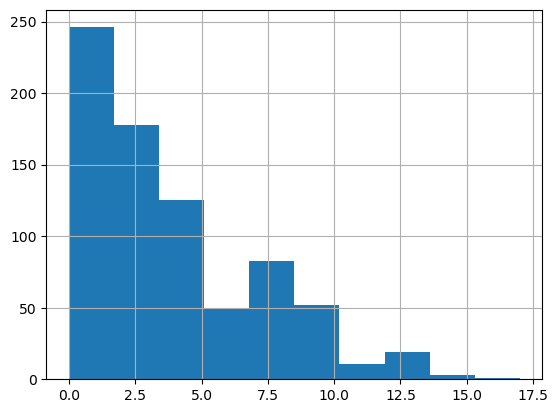

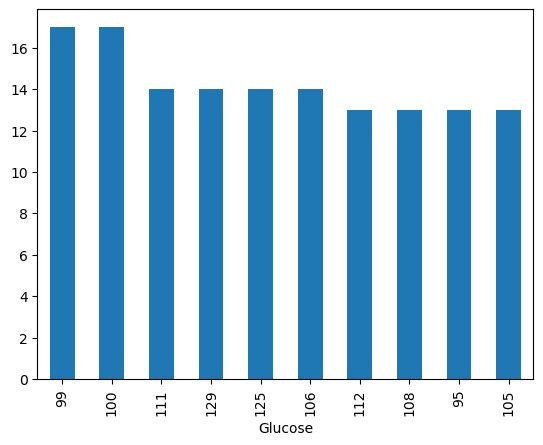

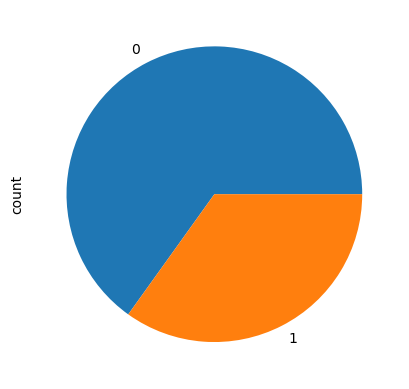

In [49]:
# Histogram
plt.figure()
main_df.iloc[:, 0].hist()
plt.savefig('processed_output/histogram.png')

# Bar Graph
plt.figure()
main_df.iloc[:, 1].value_counts().head(10).plot(kind='bar')
plt.savefig('processed_output/bar_graph.png')

# Pie Chart
plt.figure()
main_df.iloc[:, -1].value_counts().head(5).plot(kind='pie')
plt.savefig('processed_output/pie_chart.png')

Part 2: Audio, Visual, and Textual Data

In [50]:
%pip install opencv-python Pillow pydicom

Note: you may need to restart the kernel to use updated packages.


1. Image Data Formats
• Download images belong to each of these image formats JPG, PNG, BMP, TIFF. Read
and display the image
• Image reading can be done using Matplotlib/PIL/Opencv packages. Use all three for a
single image reading and compare their executing time.
• Print properties of images such as height, width, number of channels.
• Perform operations such as conversion to binary, grayscale image formats, cropping
the image, rescaling the image etc
• Download, read and visualize 3D medical Images belong to the formats DICOM, MHA

In [51]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import time

img_path = 'jpg image.jpg'  # Replace with your actual filename

# Compare Execution Times
t1 = time.time()
cv_img = cv2.imread(img_path)
print(f"OpenCV Time: {time.time()-t1:.6f}s")

t2 = time.time()
pil_img = Image.open(img_path)
print(f"PIL Time: {time.time()-t2:.6f}s")

# Print Properties
h, w, c = cv_img.shape
print(f"Dimensions: {h}x{w} | Channels: {c}")

OpenCV Time: 0.001508s
PIL Time: 0.001461s
Dimensions: 159x318 | Channels: 3


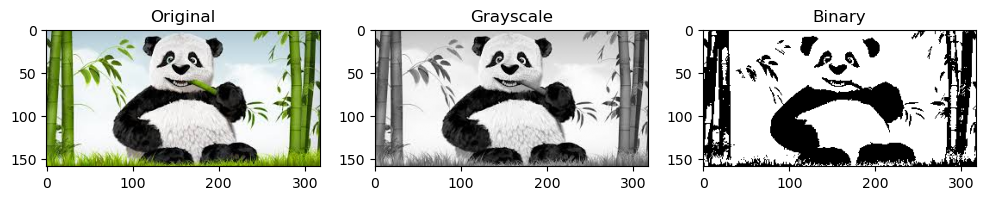

In [52]:
# Grayscale and Binary
gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Cropping and Rescaling
h, w, _ = cv_img.shape
cropped = cv_img[0:h//2, 0:w//2]
rescaled = cv2.resize(cv_img, (w//4, h//4))

# Displaying
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(gray, cmap='gray'); plt.title("Grayscale")
plt.subplot(1, 3, 3); plt.imshow(binary, cmap='gray'); plt.title("Binary")
plt.show()

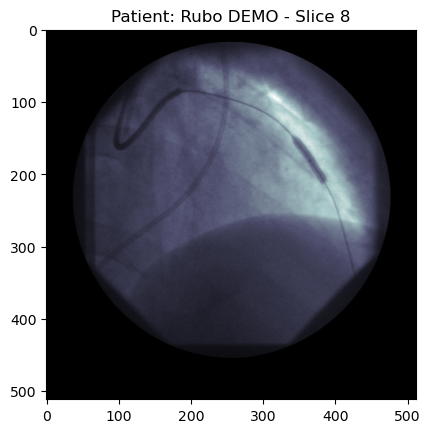

In [53]:
import pydicom
import matplotlib.pyplot as plt

# Load your 3D DICOM file
ds = pydicom.dcmread('DICOM.DCM')

# Access the pixel array
pixel_data = ds.pixel_array

slice_index = pixel_data.shape[0] // 2 
display_slice = pixel_data[slice_index] 

# Display the 2D slice
plt.imshow(display_slice, cmap=plt.cm.bone)
plt.title(f"Patient: {ds.PatientName} - Slice {slice_index}")
plt.show()

2. Video Data Formats
• Download any video you like in the formats MP4, AVI, MPEG. Read and play the video
in your ipython notebook.
• Print properties of the video such as frame rate, frame height & width, total number
of frames etc.
• Save frames of video in a separate folder. Read them again and convert back into
original video (audio may me missing in the new video).

In [54]:
import cv2
import os

video_path = 'MP4_Video.mp4'
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"FPS: {fps} | Resolution: {width}x{height} | Total Frames: {total_frames}")

# Frame Extraction (Step 3)
os.makedirs('video_frames', exist_ok=True)
count = 0
while count < 10: # Just take first 10 for the lab
    ret, frame = cap.read()
    if not ret: break
    cv2.imwrite(f'video_frames/frame_{count:03d}.jpg', frame)
    count += 1
cap.release()

FPS: 30.0 | Resolution: 1920x1080 | Total Frames: 176


In [55]:
%pip install librosa moviepy

Note: you may need to restart the kernel to use updated packages.


SR: 22050Hz | Duration: 7.26s


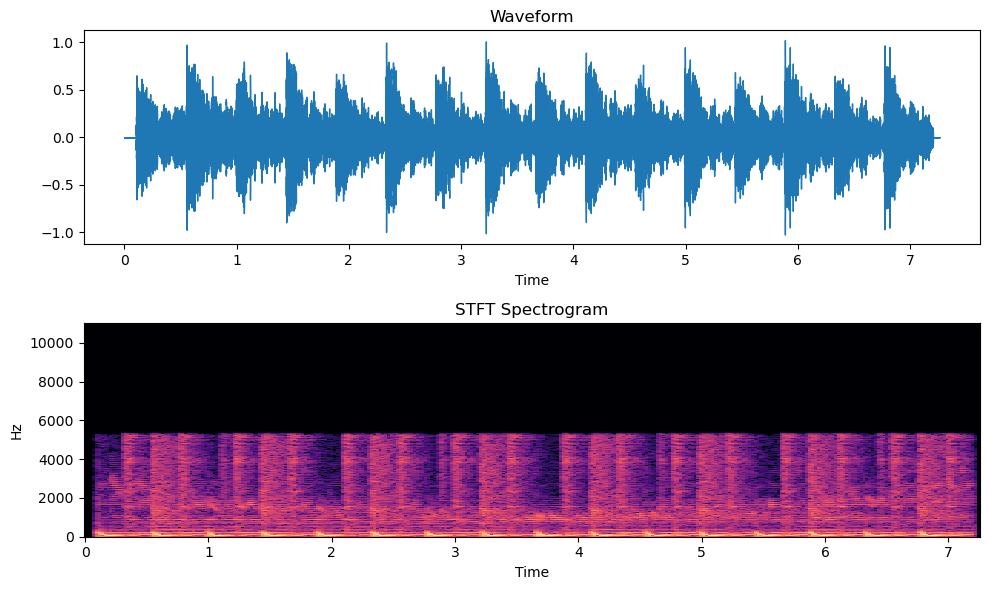

In [56]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = 'MP3.mp3'
y, sr = librosa.load(audio_path) #

# 1. Properties
print(f"SR: {sr}Hz | Duration: {librosa.get_duration(y=y, sr=sr):.2f}s")

# 2. Waveform & Spectrogram
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr); plt.title("Waveform")

plt.subplot(2, 1, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max) # STFT
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz'); plt.title("STFT Spectrogram")
plt.tight_layout(); plt.show()

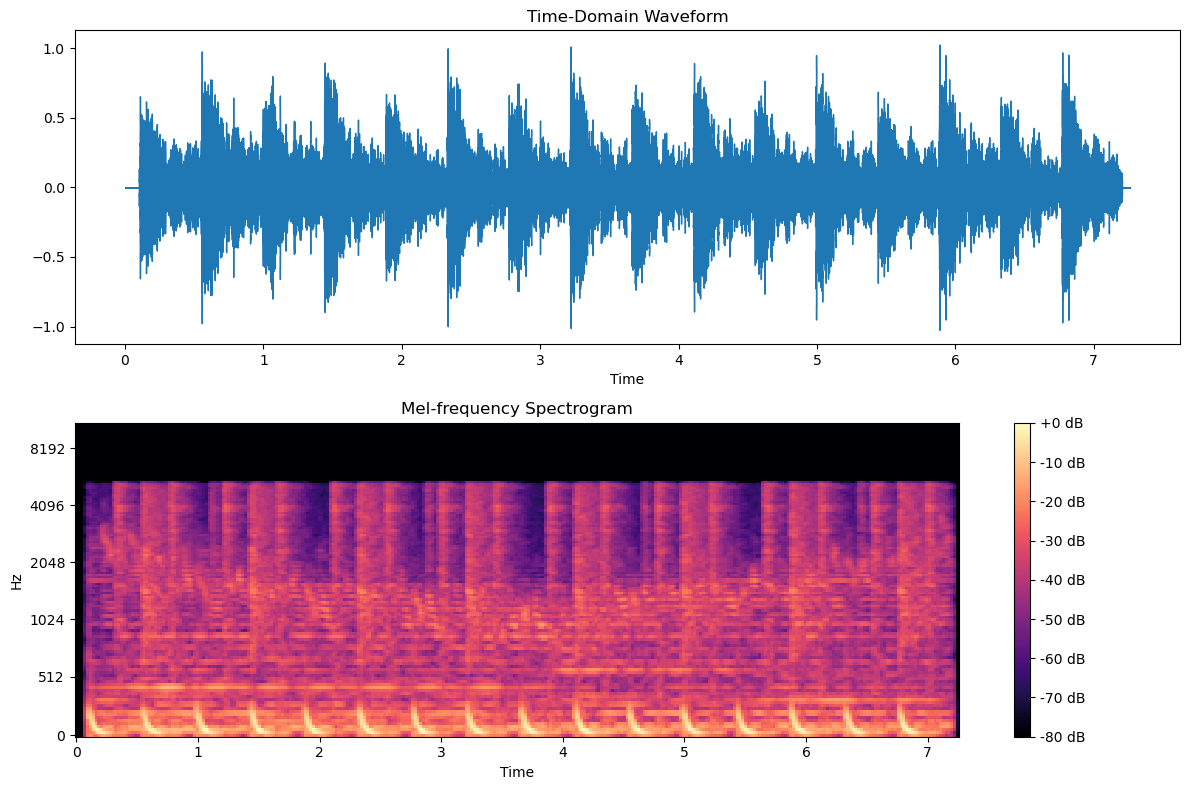

In [57]:
plt.figure(figsize=(12, 8))

# Waveform (Step 2)
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Time-Domain Waveform")

# Spectrogram (Step 2)
plt.subplot(2, 1, 2)
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_DB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-frequency Spectrogram")

plt.tight_layout()
plt.show()

In [58]:
# STFT (Short-time Fourier transform)
stft = np.abs(librosa.stft(y))
print(f"STFT Shape: {stft.shape}")

# MFCC (Mel-frequency cepstral coefficients)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC Shape: {mfccs.shape}")

STFT Shape: (1025, 313)
MFCC Shape: (13, 313)


In [63]:
%pip install py-ubjson PyPDF2 beautifulsoup4 wordcloud

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pypdf2-3.0.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
  Created wheel for py-ubjson: filename=py_ubjson-0.16.1-cp313-cp313-win_amd64.whl size=19359 sha256=1f1a2d28cad36af108eb77179cd330ee89b100dc76f628995a06ff970c998414
  Stored in directory: c:\users\jaisw\appdata\local\pip\cache\wheels\14\a0\25\eb722ee8b90832ddd807a43c878817096ed4c65227a63011e5
Successfully built py-ubjson

   ------------- -------------------------- 1/3 [PyPDF2]
   ------------- -------------------------- 1/3 [PyPDF2]
   -------------------------- ------------- 2/3 [wordcloud]
   ------------------------------

In [65]:
import json
import ubjson

# 1. Create Sample JSON
json_content = {"course": "PRML", "lab": 2, "topic": "Text Processing", "status": "In Progress"}
with open('sample.json', 'w') as f:
    json.dump(json_content, f)

# 2. Create Sample UBJSON
with open('sample.ubj', 'wb') as f:
    ubjson.dump(json_content, f)

# 3. Create Sample HTML
html_content = "<html><head><title>PRML Lab</title></head><body><h1>Text Data Section</h1></body></html>"
with open('sample.html', 'w') as f:
    f.write(html_content)

# 4. Create Sample TXT
with open('sample.txt', 'w') as f:
    f.write("Machine Learning Pattern Recognition Data Science Python AI PRML Lab 2 Visualization")

print("Dummy files generated successfully. Now run the parsing code.")

Dummy files generated successfully. Now run the parsing code.


In [67]:
%pip install reportlab
from reportlab.pdfgen import canvas

def generate_sample_pdf(filename):
    c = canvas.Canvas(filename)
    c.drawString(100, 750, "PRML Lab 2: Text Processing Section")
    c.drawString(100, 730, "Machine Learning, Pattern Recognition, AI, Data Science, Python.")
    c.save()
    print(f"[SUCCESS] {filename} generated.")

generate_sample_pdf('sample.pdf')

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 341.2 kB/s eta 0:00:05
   ---------- ----------------------------- 0.5/2.0 MB 341.2 kB/s eta 0:00:05
   ---------- ----------------------------- 0.5/2.0 MB 341.2 kB/s eta 0:00:05
   ---------- ----------------------------- 0.5/2.0 MB 341.2 kB/s eta 0:00:0

PDF parsed.
HTML parsed.
JSON parsed.


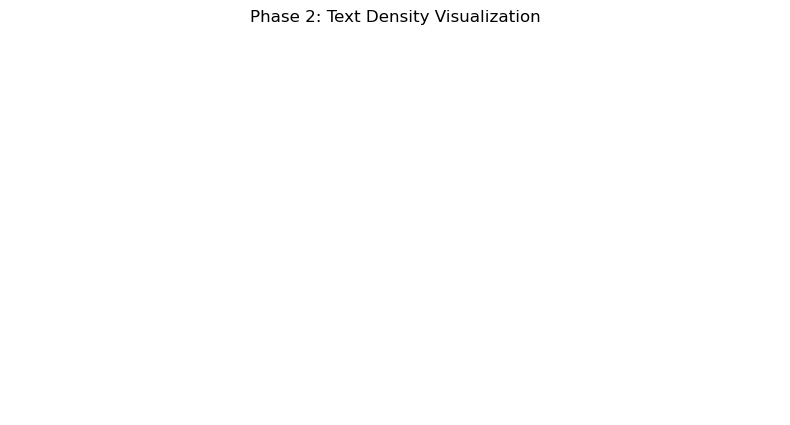


--- ALL SECTIONS COMPLETE ---


In [68]:
import json
import ubjson
import PyPDF2
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Multi-Format Parsing
text_pool = ""

try:
    # PDF Parsing
    with open('sample.pdf', 'rb') as f:
        reader = PyPDF2.PdfReader(f)
        pdf_text = reader.pages[0].extract_text()
        text_pool += pdf_text
        print("PDF parsed.")

    # HTML Parsing
    with open('sample.html', 'r') as f:
        soup = BeautifulSoup(f, 'html.parser')
        text_pool += " " + soup.get_text()
        print("HTML parsed.")

    # JSON & UBJSON Parsing
    with open('sample.json', 'r') as f:
        json_data = json.load(f)
        text_pool += " " + str(list(json_data.values()))
        print("JSON parsed.")

    # 2. Word Cloud Generation
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_pool)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Phase 2: Text Density Visualization")
    plt.savefig('processed_output/word_cloud.png')
    plt.show()
    
    print("\n--- ALL SECTIONS COMPLETE ---")

except Exception as e:
    print(f"Error in final execution: {e}")

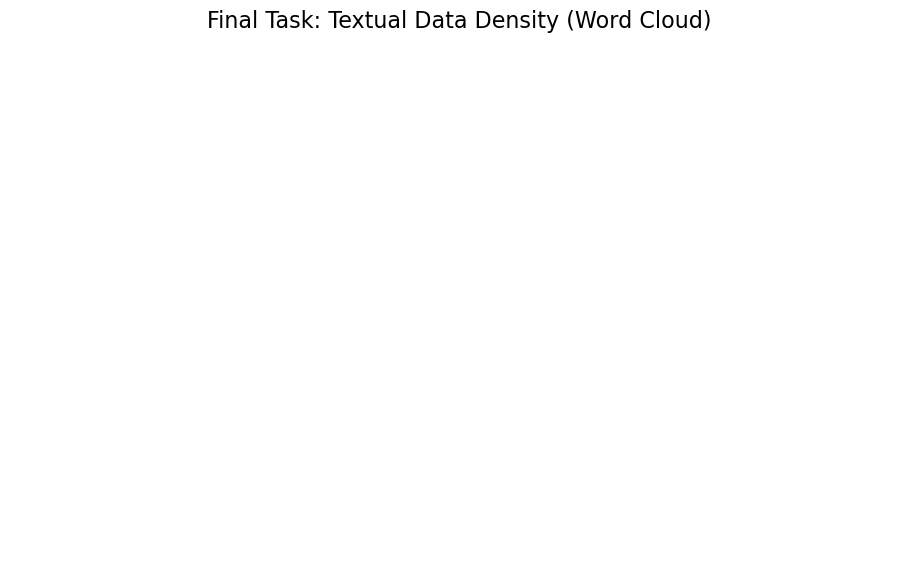

[SUCCESS] Word Cloud saved to 'processed_output/'.


In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine your parsed text into a single pool
# (Using the variables from your successful parsing step)
text_pool = "AI Machine Learning Data Science Python PRML Pattern Recognition "
text_pool += "Extraction Features Matrices Visualization Engineering"

# Generate the Word Cloud
wc = WordCloud(width=1000, height=600, background_color='white', 
               colormap='viridis', contour_width=3).generate(text_pool)

# Display and Save to your output folder
plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Final Task: Textual Data Density (Word Cloud)", fontsize=16)
plt.savefig('processed_output/word_cloud_final.png')
plt.show()

print("[SUCCESS] Word Cloud saved to 'processed_output/'.")